# Endymion Viva Demo
## Lunar Terrain Hazard Assessment and Hazard-Aware Navigation

This notebook demonstrates the final Endymion pipeline by:

- loading saved artefacts from the official CLI runners,
- visualising terrain, hazard, and navigation outputs,
- reviewing benchmark comparison results,
- inspecting the machine-learning crater-probability output,
- and optionally creating one fresh navigation run during the viva.

This notebook is intended for the final video demonstration and viva

## Demo flow

This notebook follows the same logic as the final Endymion system:

1. Load saved ROI artefacts
2. Inspect terrain-derived products
3. Visualise hazard and route outputs
4. Review benchmark summaries
5. Review ML bridge outputs
6. Optionally generate one fresh route live
7. Summarise what the system demonstrates

The main CLI runners remain the execution interface:

- `python src/run_endymion.py`
- `python benchmark/run_benchmark.py`
- `python src/run_crater_ml.py`

### Setup and Paths

In [1]:
# - This notebook is a presentation layer for the final Endymion system.
# - It is based on the final runner-oriented workflow described in the report:
#     * official pipeline runner
#     * benchmark runner
#     * ML bridge runner
# - Main idea:
#     CLI runs the system
#     notebook explains and visualises the system

from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Main base paths
PERSISTENT_DIR = Path(r"C:\Endymion\persistent")
RUNTIME_DIR = Path(r"C:\Endymion\runtime")

# Canonical ROI path used in the final report
ROI_DIR = PERSISTENT_DIR / "derived" / "ldem_80s_20m" / "roi_14688_15712_14688_15712"

# Main runner paths
REPO_ROOT = Path(r"C:\Users\yairc\Endymion\Endymion")
PIPELINE_RUNNER = REPO_ROOT / "src" / "run_endymion.py"
ML_RUNNER = REPO_ROOT / "src" / "run_crater_ml.py"
BENCHMARK_RUNNER = REPO_ROOT / "benchmark" / "run_benchmark.py"

# Main benchmark and ML locations
BENCHMARK_DIR = ROI_DIR / "benchmarks" / "benchmark_phase2_ml_cli"
ML_SUMMARY_PATH = ROI_DIR / "crater_proba_ml_v1_summary.json"

print("ROI_DIR:", ROI_DIR)
print("BENCHMARK_DIR:", BENCHMARK_DIR)
print("ML_SUMMARY_PATH:", ML_SUMMARY_PATH)
print("Notebook interpreter:", sys.executable)

ROI_DIR: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712
BENCHMARK_DIR: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\benchmarks\benchmark_phase2_ml_cli
ML_SUMMARY_PATH: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_proba_ml_v1_summary.json
Notebook interpreter: c:\Users\yairc\Endymion\Endymion\.venv\Scripts\python.exe


### Check Artifact Existance 

This section confirms that the notebook is reading from the saved Endymion artefact structure rather than from hidden manual steps.

In [2]:
# - The final Endymion pipeline stores outputs through a stable artefact contract.
# - This cell checks for the main terrain, crater, benchmark, and ML artefacts used in the demo.

expected_files = {
    "DEM": ROI_DIR / "dem_m.npy",
    "Slope": ROI_DIR / "slope_deg.npy",
    "Roughness": ROI_DIR / "roughness_rms.npy",
    "Crater mask": ROI_DIR / "crater_mask.npy",
    "Crater probability": ROI_DIR / "crater_proba_ml_v1.npy",
    "Benchmark summary CSV": BENCHMARK_DIR / "summary.csv",
    "ML summary JSON": ML_SUMMARY_PATH,
}

# Check for the existence of expected files and print their status
for label, path in expected_files.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{label:24} -> {status} | {path}")

DEM                      -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\dem_m.npy
Slope                    -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\slope_deg.npy
Roughness                -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\roughness_rms.npy
Crater mask              -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_mask.npy
Crater probability       -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_proba_ml_v1.npy
Benchmark summary CSV    -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\benchmarks\benchmark_phase2_ml_cli\summary.csv
ML summary JSON          -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_proba_ml_v1_summary.json


### Load terrain-derived artefacts

These are the core ROI-aligned terrain products generated by the Endymion pipeline.


In [3]:
# - These artefacts come from the derived terrain stage of the Endymion pipeline:
#     dem_m.npy
#     slope_deg.npy
#     roughness_rms.npy
# - They form the base input for hazard generation and later ML processing.

dem_m = np.load(ROI_DIR / "dem_m.npy")
slope_deg = np.load(ROI_DIR / "slope_deg.npy")
roughness_rms = np.load(ROI_DIR / "roughness_rms.npy")

# print basic info about the loaded arrays to confirm they are correctly loaded
print("DEM shape:", dem_m.shape, dem_m.dtype)
print("Slope shape:", slope_deg.shape, slope_deg.dtype)
print("Roughness shape:", roughness_rms.shape, roughness_rms.dtype)


DEM shape: (1024, 1024) float32
Slope shape: (1024, 1024) float32
Roughness shape: (1024, 1024) float32


### Visualise terrain products

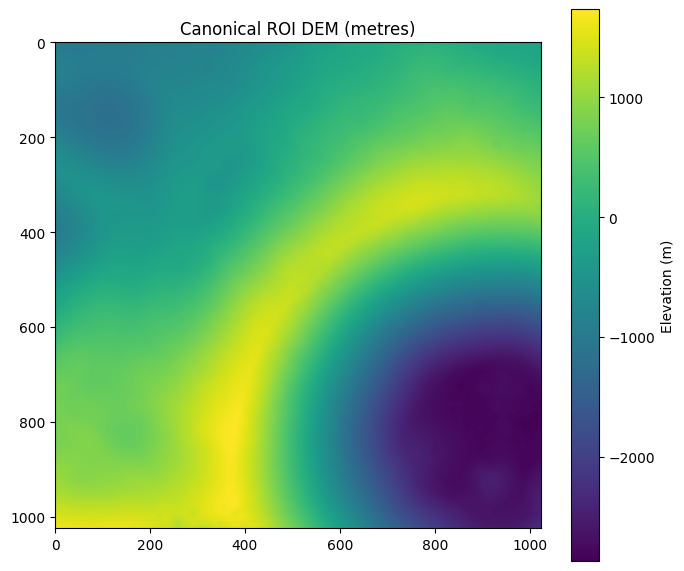

In [4]:
# DEM visualisation

plt.figure(figsize=(7, 6))
plt.imshow(dem_m)
plt.title("Canonical ROI DEM (metres)")
plt.colorbar(label="Elevation (m)")
plt.tight_layout()
plt.show()

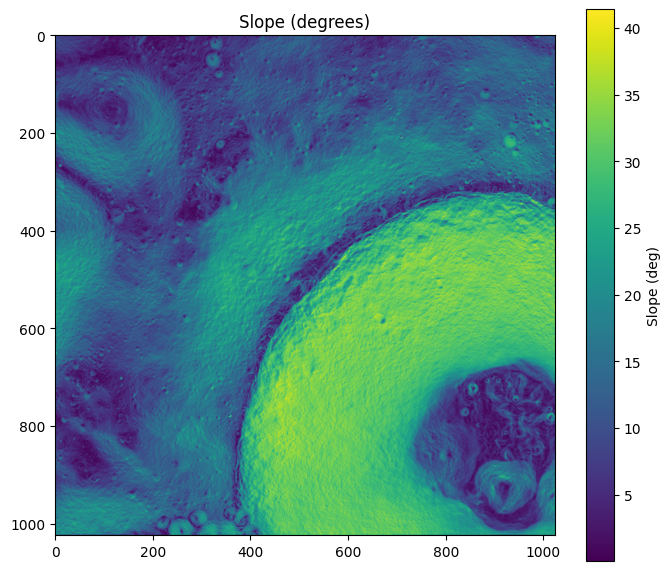

In [5]:
# Slope visualisation

plt.figure(figsize=(7, 6))
plt.imshow(slope_deg)
plt.title("Slope (degrees)")
plt.colorbar(label="Slope (deg)")
plt.tight_layout()
plt.show()

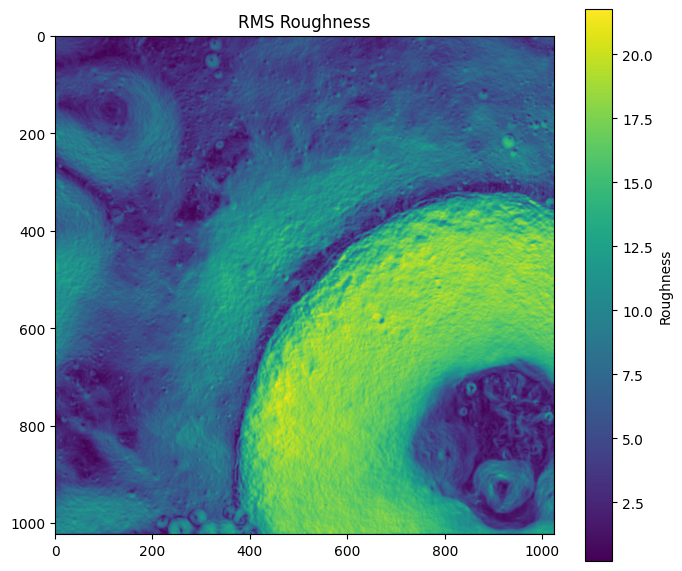

In [6]:
# Roughness visualisation

plt.figure(figsize=(7, 6))
plt.imshow(roughness_rms)
plt.title("RMS Roughness")
plt.colorbar(label="Roughness")
plt.tight_layout()
plt.show()

### Load Saved navigation run

This section loads one existing saved navigation run so the route, hazard map, and evaluator outputs can be inspected quickly and reliably.

In [7]:
# - This section loads one saved navigation run from the final Endymion artefact contract:
#     hazard.npy, cost.npy, path_rc.npy, nav_meta.json, metrics.json
# - You can change the run folder name below if needed.

saved_run_name = "terrain_only_smoke_test_v2"   # can change 
RUN_DIR = ROI_DIR / "navigation" / saved_run_name


if not RUN_DIR.exists():
    raise FileNotFoundError(f"Saved run not found: {RUN_DIR}")

hazard = np.load(RUN_DIR / "hazard.npy")
cost = np.load(RUN_DIR / "cost.npy")
path_rc = np.load(RUN_DIR / "path_rc.npy")


with open(RUN_DIR / "nav_meta.json", "r", encoding="utf-8") as f:
    nav_meta = json.load(f)

# Extract navigation information from the loaded nav_meta.json
nav = nav_meta.get("nav_meta", nav_meta)
start_rc = tuple(nav["start_rc"])
goal_rc = tuple(nav["goal_rc"])

# check if metrics.json exists and load it if it does
metrics = None
metrics_path = RUN_DIR / "metrics.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

# Print out the loaded navigation results and metrics
print("RUN_DIR:", RUN_DIR)
print("Start:", start_rc)
print("Goal :", goal_rc)
print("Path nodes:", len(path_rc))
print("Success:", nav.get("result", {}).get("success", None))

RUN_DIR: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\navigation\terrain_only_smoke_test_v2
Start: (269, 499)
Goal : (122, 558)
Path nodes: 155
Success: True


### Route visualisation

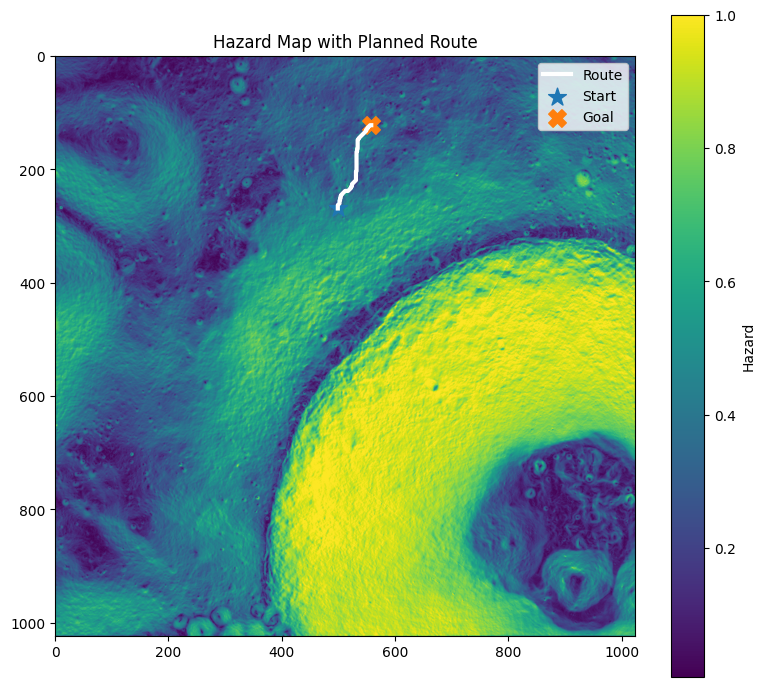

In [8]:
# - This plot is intentionally simple and presentation-friendly.
# - The route is thicker and the start/goal markers are clearly visible for the viva and FVD.

plt.figure(figsize=(8, 7))
plt.imshow(hazard)
plt.title("Hazard Map with Planned Route")
plt.colorbar(label="Hazard")

if len(path_rc) > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], linewidth=3, color="white", label="Route")

plt.scatter(start_rc[1], start_rc[0], s=180, marker="*", label="Start")
plt.scatter(goal_rc[1], goal_rc[0], s=160, marker="X", label="Goal")

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Saved run summary


In [9]:
# - This cell gives a compact summary of one run so the notebook can answer viva questions quickly.

result = nav.get("result", {})

print("=== Saved Run Summary ===")
print("Run folder:", RUN_DIR.name)
print("Success:", result.get("success"))
print("Failure reason:", result.get("failure_reason"))
print("Total cost:", result.get("total_cost"))
print("Expansions:", result.get("expansions"))

if metrics is not None:
    geometry = metrics.get("geometry", {})
    safety = metrics.get("safety", {})
    efficiency = metrics.get("efficiency", {})

    print("\n=== Evaluator Metrics ===")
    print("Path length (m):", geometry.get("path_length_m"))
    print("Mean path hazard:", safety.get("path_hazard_mean"))
    print("Max path hazard :", safety.get("path_hazard_max"))
    print("Cost per metre  :", efficiency.get("cost_per_m"))

=== Saved Run Summary ===
Run folder: terrain_only_smoke_test_v2
Success: True
Failure reason: None
Total cost: 636.4488525390625
Expansions: 8807

=== Evaluator Metrics ===
Path length (m): 3510.7821048680194
Mean path hazard: 0.2659058178985311
Max path hazard : 0.4357956051826477
Cost per metre  : 0.16154634529362283


## Navigation Demo

This section can either:

- load an existing saved run, or
- creates one fresh route using the official Endymion runner.

To change the route, only edit `start_rc` and `goal_rc` in the next cell.

In [11]:
# - Keeps the navigation section simple for the viva.
# - Uses the official Endymion runner when a fresh run is requested.
# - Avoids `python -m src.run_endymion` issues by calling the script directly.
# - User only needs to edit:
#     * use_live_run
#     * start_rc
#     * goal_rc

# --- Simple user controls ---
use_live_run = True          # False = load saved run, True = create fresh run
start_rc = (769, 199)         # edit if desired (must be within the ROI)
goal_rc  = (192, 458)         # edit if desired (must be within the ROI)

# Saved run to use when use_live_run = False
saved_run_name = "terrain_only_smoke_test_v2"

# Live run prefix when use_live_run = True
live_run_prefix = "viva_live_demo" # will update name if another run with the same prefix is found to avoid overwriting previous runs

TIF_PATH = r"C:\Endymion\persistent\LDEM_80S_20MPP_ADJ.TIF"

nav_root = ROI_DIR / "navigation"

if use_live_run:
    cmd = [
        sys.executable,
        str(PIPELINE_RUNNER),
        "--persistent-dir", str(PERSISTENT_DIR),
        "--runtime-dir", str(RUNTIME_DIR),
        "--tif-path", TIF_PATH,
        "--run-name", live_run_prefix,
        "--start", str(start_rc[0]), str(start_rc[1]),
        "--goal", str(goal_rc[0]), str(goal_rc[1]),
    ]

    print("Running fresh navigation...")
    print(" ".join(cmd))
    print("-" * 80)

    result = subprocess.run(
        cmd,
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.stderr:
        print("-" * 80)
        print("STDERR:")
        print(result.stderr)

    print("Return code:", result.returncode)

    candidates = sorted(
        [p for p in nav_root.iterdir() if p.is_dir() and p.name.startswith(live_run_prefix)],
        key=lambda p: p.stat().st_mtime
    )

    if not candidates:
        raise FileNotFoundError("No live run folder found after execution.")

    ACTIVE_RUN_DIR = candidates[-1]

else:
    ACTIVE_RUN_DIR = nav_root / saved_run_name
    if not ACTIVE_RUN_DIR.exists():
        raise FileNotFoundError(f"Saved run not found: {ACTIVE_RUN_DIR}")

print("ACTIVE_RUN_DIR:", ACTIVE_RUN_DIR)

Running fresh navigation...
c:\Users\yairc\Endymion\Endymion\.venv\Scripts\python.exe C:\Users\yairc\Endymion\Endymion\src\run_endymion.py --persistent-dir C:\Endymion\persistent --runtime-dir C:\Endymion\runtime --tif-path C:\Endymion\persistent\LDEM_80S_20MPP_ADJ.TIF --run-name viva_live_demo --start 769 199 --goal 192 458
--------------------------------------------------------------------------------
[Endymion] Initialising run...
[Endymion] Persistent dir: C:\Endymion\persistent
[Endymion] Runtime dir: C:\Endymion\runtime
[Endymion] Local GeoTIFF: C:\Endymion\persistent\LDEM_80S_20MPP_ADJ.TIF
[Endymion] Cached GeoTIFF: C:\Endymion\persistent\LDEM_80S_20MPP_ADJ.TIF
[Endymion] Initialising DataHandler...
[Endymion] Resolving ROI...
[DataHandler] Resolving canonical ROI for tile 'ldem_80s_20m' with size 1024...
[DataHandler] Resolving GeoTIFF for tile 'ldem_80s_20m'...
[DataHandler] GeoTIFF found in runtime cache: C:\Endymion\runtime\LDEM_80S_20MPP_ADJ.TIF
[DataHandler] Opening GeoTI

In [12]:
# - Loads the active navigation run selected in the previous cell.
# - Works for both saved and fresh runs.

hazard = np.load(ACTIVE_RUN_DIR / "hazard.npy")
cost = np.load(ACTIVE_RUN_DIR / "cost.npy")
path_rc = np.load(ACTIVE_RUN_DIR / "path_rc.npy")

with open(ACTIVE_RUN_DIR / "nav_meta.json", "r", encoding="utf-8") as f:
    nav_meta = json.load(f)

nav = nav_meta.get("nav_meta", nav_meta)
start_rc = tuple(nav["start_rc"])
goal_rc = tuple(nav["goal_rc"])

metrics = None
metrics_path = ACTIVE_RUN_DIR / "metrics.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

print("Start:", start_rc)
print("Goal :", goal_rc)
print("Path nodes:", len(path_rc)) 
print("Success:", nav.get("result", {}).get("success", None))

Start: (769, 199)
Goal : (192, 458)
Path nodes: 586
Success: True


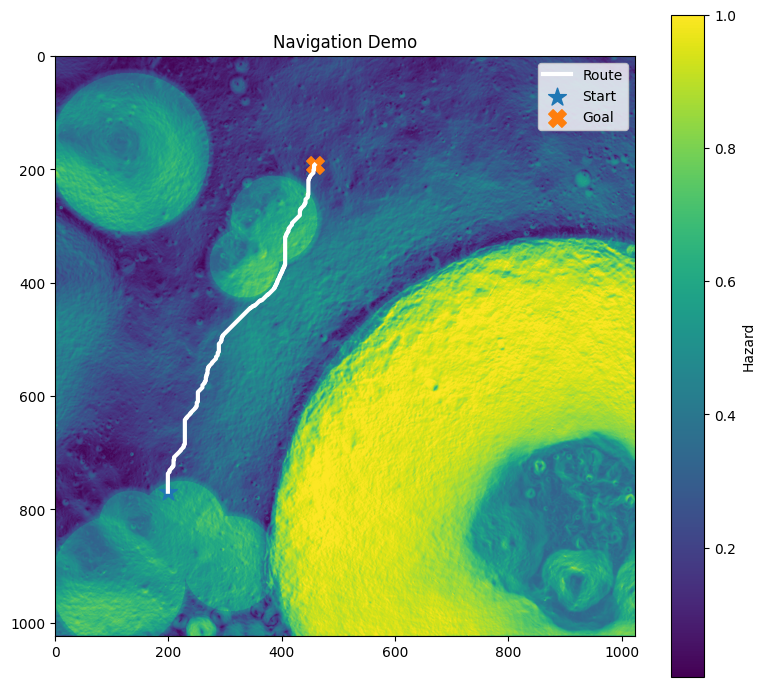

In [13]:
# - Simpler route plot for the viva:
#     * thicker route
#     * obvious start/goal markers
#     * no extra helper functions

plt.figure(figsize=(8, 7))
plt.imshow(hazard)
plt.title("Navigation Demo")
plt.colorbar(label="Hazard")

if len(path_rc) > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], linewidth=3, color="white", label="Route")

plt.scatter(start_rc[1], start_rc[0], s=180, marker="*", label="Start")
plt.scatter(goal_rc[1], goal_rc[0], s=160, marker="X", label="Goal")

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [14]:
# - Keeps the navigation section self-contained and easy to explain.

result = nav.get("result", {})

print("=== Navigation Summary ===")
print("Run folder:", ACTIVE_RUN_DIR.name)
print("Success:", result.get("success"))
print("Failure reason:", result.get("failure_reason"))
print("Total cost:", result.get("total_cost"))
print("Expansions:", result.get("expansions"))

if metrics is not None:
    geometry = metrics.get("geometry", {})
    safety = metrics.get("safety", {})
    efficiency = metrics.get("efficiency", {})

    print("\n=== Evaluator Metrics ===")
    print("Path length (m):", geometry.get("path_length_m"))
    print("Mean path hazard:", safety.get("path_hazard_mean"))
    print("Max path hazard :", safety.get("path_hazard_max"))
    print("Cost per metre  :", efficiency.get("cost_per_m"))

=== Navigation Summary ===
Run folder: viva_live_demo_v5
Success: True
Failure reason: None
Total cost: 3248.93359375
Expansions: 32168

=== Evaluator Metrics ===
Path length (m): 13779.352083112937
Mean path hazard: 0.3722550982971749
Max path hazard : 0.7036375999450684
Cost per metre  : 0.20083780836078063


### Benchmark summary

This section loads the saved benchmark outputs used to compare terrain-only, crater-aware, and ML-assisted hazard variants under the same fixed benchmark contract.

In [15]:
# - Benchmark outputs are expected inside the benchmark run directory:
#     manifest.json
#     summary.json
#     summary.csv
# - This notebook uses summary.csv for a compact comparison view.

benchmark_csv = BENCHMARK_DIR / "summary.csv"

if benchmark_csv.exists():
    bench_df = pd.read_csv(benchmark_csv)
    print("Loaded:", benchmark_csv)
    display(bench_df.head())
else:
    print("Benchmark summary.csv not found at:", benchmark_csv)



# Show only the most relevant benchmark columns

important_cols = [
    "hazard_model_id",
    "success_rate",
    "mean_path_hazard_mean",
    "mean_cost_per_m",
    "mean_expansions"
]

existing_cols = [c for c in important_cols if c in bench_df.columns]
display(bench_df[existing_cols])


Loaded: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\benchmarks\benchmark_phase2_ml_cli\summary.csv


,case_id,tier,hazard_model_id,hazard_model_kind,success,failure_reason,path_nodes,path_length_m,straight_line_m,detour_ratio,...,path_hazard_max,path_hazard_p95,haz_per_m,frac_hazard_ge_block,hazard_mean_ratio,safety_score,cost_sum_along_path,cost_per_m,planner_total_cost,expansions
0,easy_01,easy,terrain_only_v1,terrain_only,True,NaN,155,3510.782105,3167.964646,1.108214,...,0.435796,0.382100,0.011746,0.0,0.534559,0.988390,567.376761,0.161610,636.764954,8673
1,easy_01,easy,terrain_crater_v1,terrain_plus_crater,True,NaN,154,3499.066376,3167.964646,1.104516,...,0.348636,0.309018,0.009521,0.0,0.423646,0.990569,487.141733,0.139220,548.366089,8585
2,easy_01,easy,terrain_crater_ml_v1,terrain_plus_crater_ml,True,NaN,155,3510.782105,3167.964646,1.108214,...,0.375579,0.328710,0.010114,0.0,0.454144,0.989987,510.095105,0.145294,572.668152,8608
3,easy_02,easy,terrain_only_v1,terrain_only,True,NaN,281,6262.741700,5824.087911,1.075317,...,0.694658,0.594635,0.018055,0.0,0.808520,0.982265,1411.742555,0.225419,1602.797852,15351
4,easy_02,easy,terrain_crater_v1,terrain_plus_crater,True,NaN,281,6262.741700,5824.087911,1.075317,...,0.555727,0.475708,0.015180,0.0,0.662540,0.985047,1231.656764,0.196664,1389.356201,15306


,hazard_model_id
0,terrain_only_v1
1,terrain_crater_v1
2,terrain_crater_ml_v1
3,terrain_only_v1
4,terrain_crater_v1
5,terrain_crater_ml_v1
6,terrain_only_v1
7,terrain_crater_v1
8,terrain_crater_ml_v1
9,terrain_only_v1


### ML bridge output

This section loads the machine-learning crater-probability artefact and its summary outputs.


Crater probability shape: (1024, 1024) float32


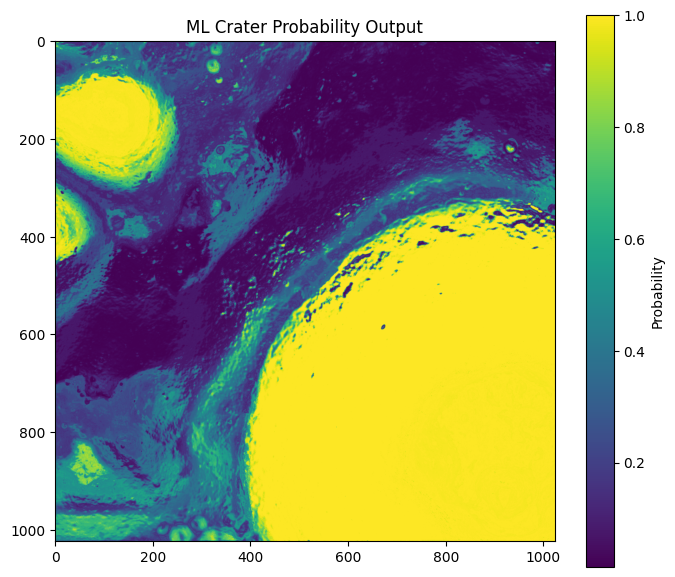

=== ML Summary ===
Accuracy : 0.7941123560855263
Precision: 0.8942408877834115
Recall   : 0.7291341653666147
F1-score : 0.803291367679285


In [ ]:
# - Based on run_crater_ml.py summary structure:
#   metrics are saved under "evaluation", not "metrics".
# - Source checked from the current Endymion ML bridge implementation.

ml_proba_path = ROI_DIR / "crater_proba_ml_v1.npy"

if ml_proba_path.exists():
    crater_proba = np.load(ml_proba_path)
    print("Crater probability shape:", crater_proba.shape, crater_proba.dtype)
else:
    crater_proba = None
    print("crater_proba_ml_v1.npy not found.")


# ML crater probability visualisation
if crater_proba is not None:
    plt.figure(figsize=(7, 6))
    plt.imshow(crater_proba)
    plt.title("ML Crater Probability Output")
    plt.colorbar(label="Probability")
    plt.tight_layout()
    plt.show()


# Load ML summary JSON
if ML_SUMMARY_PATH.exists():
    with open(ML_SUMMARY_PATH, "r", encoding="utf-8") as f:
        ml_summary = json.load(f)

    evaluation = ml_summary.get("evaluation", {})

    print("=== ML Summary ===")
    print("Accuracy :", evaluation.get("accuracy"))
    print("Precision:", evaluation.get("precision"))
    print("Recall   :", evaluation.get("recall"))
    print("F1-score :", evaluation.get("f1"))
else:
    print("ML summary JSON not found.")

## Main CLI commands used in Endymion

Official pipeline runner:  
`python src/run_endymion.py`

Benchmark runner:  
`python benchmark/run_benchmark.py`

ML bridge:  
`python src/run_crater_ml.py`

## Final takeaway

This notebook demonstrates that Endymion is not just a collection of experiments, but a reproducible hazard-navigation framework.

It shows:

- terrain-derived products loaded from a stable canonical ROI,
- hazard-aware route generation from saved pipeline artefacts,
- benchmark comparison under fixed planning conditions,
- and a machine-learning bridge that produces an ROI-aligned crater-probability raster.

In the final project, the terrain-only baseline remained the strongest overall in robustness and search effort, while crater-aware and ML-assisted variants demonstrated that richer hazard signals could be integrated and compared under the same controlled benchmark contract.

Author : Yair Cortes Torres - w20475998